In [1]:
import pandas as pd
import io
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pyfonts import load_google_font

In [2]:
def load_and_clean(filepath):
    # Read file into memory as one string
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()

    # Replace invalid escape sequence
    text = text.replace(r"rgb\(101,67,33\)", "brown")

    # Load into df
    df = pd.read_csv(io.StringIO(text))

    # Remove trailing whitespace 
    df = df.apply(lambda x: x.str.strip())

    # Rename second column 
    df.rename(columns={df.columns[1]: "color"}, inplace=True)

    # Create new column from first column and remove last 2 characters
    df["APPLING"] = df[df.columns[0]].str[:-2]

    # Drop original first column
    df.drop(columns=[df.columns[0]], inplace=True)

    # Drop duplicate rows based on new column
    df.drop_duplicates(subset=["APPLING"], keep="first", inplace=True)

    return df

In [3]:
# Apply load and clean function
df1870 = load_and_clean("ga1870pop.csv")
df1880 = load_and_clean("ga1880pop.csv")

In [4]:
# Rename color columns
df1870.rename(columns={"color": "color1870"}, inplace=True)
df1880.rename(columns={"color": "color1880"}, inplace=True)

In [5]:
df1870.shape

(137, 2)

In [6]:
df1880.shape

(137, 2)

In [7]:
# Merge dfs
df = pd.merge(df1870, df1880, on="APPLING")

In [8]:
df.shape

(137, 3)

# Map

In [9]:
# Load Georgia shape file
georgia = gpd.read_file("shape files/DuBoisChallenge - Georgia Counties w 1870 & 1880 data.shp")
# Select relevant columns
georgia = georgia[["ICPSRNAM", "geometry"]]

In [10]:
georgia.shape

(137, 2)

# Merge georgia with df

In [11]:
gdf = pd.merge(georgia, df, left_on="ICPSRNAM", right_on="APPLING")

In [12]:
gdf.shape

(137, 5)

# Colors

In [13]:
# Color dictionary
color_dict = {
    "blue": {
        "color": "#3b2f76",
        "pop": "BETWEEN 20.000 AND 30.000",        
    },
    "brown": {
        "color": "#624125",
        "pop": "15.000 TO 20.000",        
    },
    "tan": {
        "color": "#b79a7c",
        "pop": "10.000 TO 15.000",        
    },
    "crimson": {
        "color": "#c8003b",
        "pop": "5.000 TO 10.000",        
    },
    "pink": {
        "color": "#d89a93",
        "pop": "2.500 TO 5.000",        
    },
    "gold": {
        "color": "#f0b900",
        "pop": "1.000 TO 2.500",        
    },
    "green": {
        "color": "#3f513f",
        "pop": "UNDER 1.000",        
    }
}

In [14]:
# Columns to map
columns_to_map = ["color1870", "color1880"]

# Apply mapping with a default color
for col in columns_to_map:
    gdf[col + "_mapped"] = gdf[col].map(lambda x: color_dict.get(x, {}).get("color", "#F3E6DE")) #F6EAE4

In [15]:
# Custom font
font = load_google_font("Public Sans", weight="bold")

# Plot

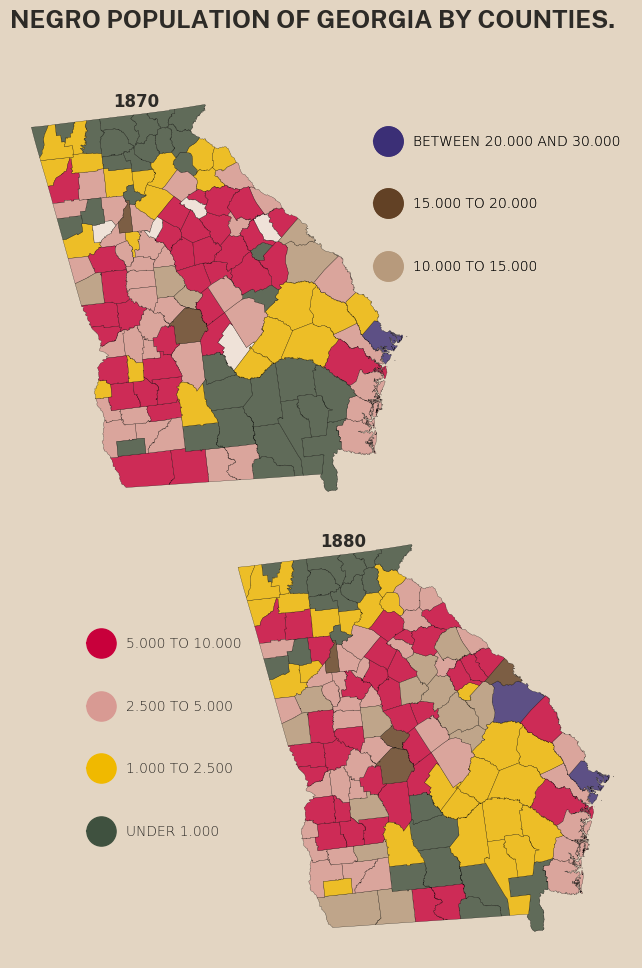

In [16]:
# layout scheme
scheme = """
AAB
CDD
"""
# Create figure
fig, axs = plt.subplot_mosaic(scheme, figsize=(8, 10), facecolor=("#e3d5c2"))
# Adjust the spacing between axes
plt.subplots_adjust(wspace=0, hspace=0, bottom=0)

# Remove axis
for ax in axs:    
    axs[ax].axis("off")

# Plot maps
gdf.plot(ax=axs["A"], color=gdf["color1870_mapped"], alpha=0.8, ec="black", lw=0.2)
gdf.plot(ax=axs["D"], color=gdf["color1880_mapped"], alpha=0.8, ec="black", lw=0.2)

# Add title for subplots
axs["A"].set_title("1870", x=0.3, y=0.93, weight="bold", alpha=0.8)
axs["D"].set_title("1880", x=0.3, y=0.93, weight="bold", alpha=0.8)

# Split keys for the two legends
keys1 = list(color_dict.keys())[:3]  
keys2 = list(color_dict.keys())[3:]  

# Create handles for scatter legend
legend_handles1 = [
    Line2D([], [], marker="o", color=color_dict[k]["color"],
           markerfacecolor=color_dict[k]["color"], markersize=21,
           label=color_dict[k]["pop"])          
    for k in keys1
]

legend_handles2 = [
    Line2D([], [], marker="o", color=color_dict[k]["color"],
           markerfacecolor=color_dict[k]["color"], markersize=21,
           label=color_dict[k]["pop"])          
    for k in keys2
]

# Add first legend
legend1 = axs["B"].legend(handles=legend_handles1,
                          loc="upper right",
                          bbox_to_anchor=(1, 0.9),
                          labelspacing = 3.5,
                          fontsize="medium",
                          facecolor="#e0d3c1",
                          frameon = False)
axs["B"].add_artist(legend1)  

# Add second legend
legend2=axs["C"].legend(handles=legend_handles2,
                        loc="center left",
                        bbox_to_anchor=(0.3, 0.5),
                        labelspacing = 3.5,
                        fontsize="medium",
                        facecolor="#e0d3c1",
                        frameon = False)

# Control text in legend
for text in legend1.get_texts() + legend2.get_texts():
    text.set_alpha(0.8)
    text.set_color("black")    
    text.set_fontweight("light")   

# Add title 
fig.text(0.5, 0.93, "NEGRO POPULATION OF GEORGIA BY COUNTIES.", alpha=0.8, font=font, size=18, ha="center")

plt.show()

# Saving the figure
#plt.savefig("plate06.jpg")

In [17]:
import numpy as np
import matplotlib.image as mpimg
from PIL import Image

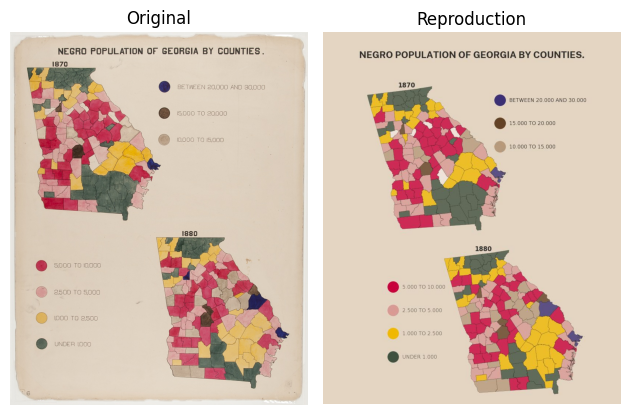

In [18]:
# Load images 
image1 = Image.open("original-plate-06.jpg")
image2 = Image.open("plate06.jpg")

# Convert to numpy arrays
images = [np.array(image1), np.array(image2)]
titles = ["Original", "Reproduction"]

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2)

# Loop through axes, images, and titles
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title)

# Adjust the layout and show
plt.tight_layout()
plt.show()

# Save the combined figure 
#plt.savefig("plate06sidebyside.png", dpi=300)